# Exploring Satellite Passes - Monotonic Concave Cal Edition

In [1]:
import os
from pathlib import Path

import h5py
import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC

from embers_passes import PassFile

import mwa_hyperbeam
# wget http://ws.mwatelescope.org/static/mwa_full_embedded_element_pattern.h5
os.environ["MWA_BEAM_FILE"] = "../../hyperbeam/mwa_full_embedded_element_pattern.h5"

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.8, 256)))
prd.set_under("white")

In [2]:
def hyperbeam_healpix(
    beam,
    nside: int = 32,
    freq_hz: float = 137e6,
    delays=np.zeros(16, dtype=int),
    amps=np.ones(16),
    norm_to_zenith: bool = True,
    parallactic: bool = False,
) -> np.ndarray:
    """Evaluate the MWA Hyperbeam model on an above-horizon HEALPix grid.
    The beam is evaluated for all HEALPix pixels with zenith angle
    0 <= ZA <= pi/2, corresponding to the upper hemisphere. For a HEALPix
    map with npix = 12 * nside**2 pixels, this includes npix // 2 pixels.

    Parameters
    ----------
    beam
        Initialized mwa_hyperbeam.FEEBeam object.
    nside
        HEALPix NSIDE parameter defining the angular resolution of the grid.
    freq_hz
        Frequency at which to evaluate the beam, in Hz.
    delays
        List of 16 beamformer delays, one per dipole. If None, all
        delays are set to zero.
    amps
        List of 16 dipole amplitudes. If ``None``, all amplitudes are set
        to unity.
    norm_to_zenith
        If True, normalize the beam response to unity at zenith.
    parallactic
        If True, include parallactic-angle rotation.

    Returns
    -------
    beam_db
        Array of shape ``(npix // 2, 2)`` containing the unpolarized beam
        response in dB for all above-horizon pixels. Column 0 contains the
        XX polarization and column 1 contains the YY polarization.

    Notes
    -----
    The beam response is computed from the Jones matrices using
    ``makeUnpolInstrumentalResponse`` and converted to decibels via
    ``10 * log10(power)``.
    Any pixels with non-positive power will yield ``-inf``.
    """
    # if delays is None:
    #     delays = [0] * 16

    # if amps is None:
    #     amps = [1.0] * 16

    # if len(delays) != 16:
    #     raise ValueError(f"Expected 16 delays, got {len(delays)}.")

    # if len(amps) != 16:
    #     raise ValueError(f"Expected 16 amplitudes, got {len(amps)}.")

    npix = hp.nside2npix(nside)
    above_horizon = np.arange(npix // 2)

    za, az = hp.pix2ang(nside, above_horizon)

    jones = beam.calc_jones_array(
        az,
        za,
        freq_hz,
        delays,
        amps,
        norm_to_zenith,
        parallactic,
    )

    unpol_beam = make_unpol_instrumental_response(jones, jones)

    beam_xx = np.real(unpol_beam[:, 0])
    beam_yy = np.real(unpol_beam[:, 3])

    beam_db_xx = 10.0 * np.log10(beam_xx)
    beam_db_yy = 10.0 * np.log10(beam_yy)

    return np.column_stack([beam_db_xx, beam_db_yy])

In [3]:
def make_unpol_instrumental_response(j1: np.ndarray, j2: np.ndarray) -> np.ndarray:
    """
    Convert Jones matrices to unpolarized instrumental beam responses.

    Parameters
    ----------
    j1, j2 : np.ndarray
        Arrays of Jones terms with shape (N, 4), where the Jones matrix is
        flattened as [j00, j01, j10, j11].

    Returns
    -------
    np.ndarray
        Array of shape (N, 4) containing [XX, XY, YX, YY] instrumental
        responses for an unpolarized source.
    """
    result = np.empty_like(j1)

    result[:, 0] = j1[:, 0] * j2[:, 0].conjugate() + j1[:, 1] * j2[:, 1].conjugate()
    result[:, 1] = j1[:, 0] * j2[:, 2].conjugate() + j1[:, 1] * j2[:, 3].conjugate()
    result[:, 2] = j1[:, 2] * j2[:, 0].conjugate() + j1[:, 3] * j2[:, 1].conjugate()
    result[:, 3] = j1[:, 2] * j2[:, 2].conjugate() + j1[:, 3] * j2[:, 3].conjugate()

    return result

In [4]:
def pass_hyperbeam_model(
    p,
    beam,
    freq_hz: float = 137e6,
    delays: list[int] | None = None,
    amps: list[float] | None = None,
    norm_to_zenith: bool = True,
    parallactic: bool = False,
) -> np.ndarray:
    """
    Evaluate the MWA hyperbeam model along a single pass.

    Parameters
    ----------
    p : PassRecord
        Pass record with alt_deg and az_deg arrays.
    beam : mwa_hyperbeam.FEEBeam
        Hyperbeam beam object.
    freq_hz : float, optional
        Frequency in Hz.
    delays : list[int], optional
        Beamformer delays.
    amps : list[float], optional
        Dipole amplitudes.
    norm_to_zenith : bool, optional
        Whether to normalize to zenith.
    parallactic : bool, optional
        Whether to include parallactic rotation.

    Returns
    -------
    np.ndarray
        Beam model in dB sampled at the pass coordinates.
    """
    if delays is None:
        delays = [0] * 16
    if amps is None:
        amps = [1.0] * 16

    az = np.radians(np.asarray(p.az_deg, dtype=float))
    za = np.radians(90.0 - np.asarray(p.alt_deg, dtype=float))

    jones = beam.calc_jones_array(
        az,
        za,
        freq_hz,
        delays,
        amps,
        norm_to_zenith,
        parallactic,
    )

    unpol_beam = make_unpol_instrumental_response(jones, jones)

    pol = p.tile[-2:]  # "XX" or "YY"

    if pol == "XX":
        model = 10.0 * np.log10(np.real(unpol_beam[:, 0]))
    elif pol == "YY":
        model = 10.0 * np.log10(np.real(unpol_beam[:, 3]))
    else:
        raise ValueError(f"Could not infer polarization from tile name: {p.tile}")

    return model

In [5]:
def passes_to_healpix(
    passes,
    nside: int = 32,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Bin satellite-pass power samples onto a HEALPix map.

    Samples from all passes are assigned to HEALPix pixels using their
    altitude and azimuth coordinates. The output power map contains the median
    of all finite power samples contributing to each pixel.

    This function is intended for older pass data that do not contain an RFE
    calibration correction field. No calibration-based thresholding or MWA
    beam-model comparison is applied.

    Parameters
    ----------
    passes : sequence of PassRecord
        Satellite-pass records. Each record must provide the attributes
        ``alt_deg``, ``az_deg``, and ``power_db``.
    nside : int, optional
        HEALPix resolution parameter. Default is 32.

    Returns
    -------
    power_map : np.ndarray
        Median measured power in each HEALPix pixel. Pixels containing no
        samples are set to NaN.
    count_map : np.ndarray
        Number of finite samples contributing to each HEALPix pixel.
    """
    npix = hp.nside2npix(nside)

    power_values: list[list[float]] = [[] for _ in range(npix)]

    for pass_record in passes:
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)

        if not (
            alt_deg.shape == az_deg.shape == power_db.shape
        ):
            raise ValueError(
                "alt_deg, az_deg, and power_db must have matching shapes."
            )

        finite = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
        )

        if not np.any(finite):
            continue

        theta = np.radians(90.0 - alt_deg[finite])
        phi = np.radians(az_deg[finite])

        pixels = hp.ang2pix(
            nside,
            theta,
            phi,
        )

        for pixel, power in zip(pixels, power_db[finite]):
            power_values[pixel].append(float(power))

    power_map = np.full(npix, np.nan, dtype=float)
    count_map = np.zeros(npix, dtype=int)

    for pixel, values in enumerate(power_values):
        count_map[pixel] = len(values)

        if values:
            power_map[pixel] = np.median(values)

    return power_map, count_map

In [6]:
def passes_to_healpix_concave_monotonic(
    passes,
    mwa_model_threshold_db: float = -10.0,
    residual_thresh: float = 2.0,
    nside: int = 32,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Bin calibrated satellite-pass samples onto HEALPix maps.

    Samples from each accepted pass are assigned to HEALPix pixels using their
    altitude and azimuth coordinates. The final power and calibration maps
    contain the median of all samples contributing to each pixel.

    Passes with a non-zero RFE calibration are compared against the MWA beam
    model. A pass is rejected when its measured power exceeds the model by
    more than ``residual_thresh`` within the region where the model response is
    above ``mwa_model_threshold_db``.

    Parameters
    ----------
    passes : sequence of PassRecord
        Satellite-pass records. Each record must provide the attributes
        ``alt_deg``, ``az_deg``, ``power_db``, and ``cal_db``. The records
        must also be compatible with :func:`pass_hyperbeam_model`.
    mwa_model_threshold_db : float, optional
        Minimum MWA model response used when testing calibrated passes, in dB
        relative to the beam maximum. Default is -10 dB.
    residual_thresh : float, optional
        Maximum permitted positive residual between the measured pass and MWA
        beam model within the selected model region, in dB. Default is 2 dB.
    nside : int, optional
        HEALPix resolution parameter. Default is 32.

    Returns
    -------
    power_map : np.ndarray
        Median measured power in each HEALPix pixel. Pixels containing no
        samples are set to NaN.
    calibration_map : np.ndarray
        Median RFE calibration correction in each HEALPix pixel. Pixels
        containing no samples are set to NaN.
    count_map : np.ndarray
        Number of individual samples contributing to each HEALPix pixel.
    """
    npix = hp.nside2npix(nside)
    beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])

    power_values: list[list[float]] = [[] for _ in range(npix)]
    calibration_values: list[list[float]] = [[] for _ in range(npix)]

    flagged_passes = 0
    flagged_samples = 0

    for pass_record in passes:
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)
        calibration_db = np.asarray(pass_record.cal_db, dtype=float)

        mwa_model_db = np.asarray(
            pass_hyperbeam_model(pass_record, beam),
            dtype=float,
        )
        residual_db = power_db - mwa_model_db

        calibration_applied = np.max(calibration_db) > 0.0
        reject_pass = False

        if calibration_applied:
            model_region = mwa_model_db > mwa_model_threshold_db

            if np.any(model_region):
                peak_residual_db = np.max(residual_db[model_region])
                reject_pass = peak_residual_db > residual_thresh

        if reject_pass:
            flagged_passes += 1
            flagged_samples += power_db.size
            continue

        theta = np.radians(90.0 - alt_deg)
        phi = np.radians(az_deg)
        pixels = hp.ang2pix(nside, theta, phi)

        for pixel, power, correction in zip(
            pixels,
            power_db,
            calibration_db,
        ):
            power_values[pixel].append(float(power))
            calibration_values[pixel].append(float(correction))

    power_map = np.full(npix, np.nan, dtype=float)
    calibration_map = np.full(npix, np.nan, dtype=float)
    count_map = np.zeros(npix, dtype=int)

    for pixel, values in enumerate(power_values):
        count_map[pixel] = len(values)

        if values:
            power_map[pixel] = np.median(values)
            calibration_map[pixel] = np.median(
                calibration_values[pixel]
            )

    n_passes = len(passes)
    accepted_samples = int(count_map.sum())
    total_samples = accepted_samples + flagged_samples

    flagged_pass_fraction = (
        100.0 * flagged_passes / n_passes
        if n_passes > 0
        else 0.0
    )
    flagged_sample_fraction = (
        100.0 * flagged_samples / total_samples
        if total_samples > 0
        else 0.0
    )

    print(
        "Flagged passes: "
        f"{flagged_pass_fraction:.2f}% "
        f"({flagged_passes}/{n_passes} passes)"
    )
    print(
        "Flagged data: "
        f"{flagged_sample_fraction:.2f}% "
        f"({flagged_samples}/{total_samples} samples)"
    )

    return power_map, calibration_map, count_map, flagged_pass_fraction, flagged_sample_fraction

In [7]:
def healpix_ew_ns_slices(
    hp_map,
    nside=None,
    za_max=90.0,
    rotate=True,
    rotation_angle=np.pi / 4,
    return_indices=False,
):
    """Return EW and NS slices through a HEALPix beam map.

    Parameters
    ----------
    hp_map : array-like
        Full-sky HEALPix map.
    nside : int, optional
        HEALPix NSIDE. If None, inferred from hp_map.
    za_max : float
        Maximum zenith angle in degrees.
    rotate : bool
        If True, rotate the map by +pi/4 before slicing. This is useful because
        NSIDE=32 maps have pixels along diagonal axes rather than cardinal axes.
    rotation_angle : float
        Rotation angle in radians.
    return_indices : bool
        If True, also return HEALPix pixel indices used for the slices.

    Returns
    -------
    slices : dict
        Dictionary with keys ``"EW"`` and ``"NS"``. Each contains
        ``(signed_za_deg, values)`` by default.

        Sign convention:
        - NS slice: negative = north, positive = south
        - EW slice: negative = east, positive = west
    """
    hp_map = np.asarray(hp_map)

    if nside is None:
        nside = hp.npix2nside(len(hp_map))

    npix = hp.nside2npix(nside)
    if len(hp_map) != npix:
        raise ValueError(f"Map has length {len(hp_map)}, expected {npix} for NSIDE={nside}.")

    if rotate:
        pix = np.arange(npix)
        theta, phi = hp.pix2ang(nside, pix)
        rotated_pix = hp.ang2pix(nside, theta, phi + rotation_angle)
        work_map = hp_map[rotated_pix]
    else:
        work_map = hp_map

    pix = np.arange(npix)
    theta, phi = hp.pix2ang(nside, pix)

    za_deg = np.degrees(theta)
    phi_deg = np.mod(np.degrees(phi), 360.0)
    phi_round = np.round(phi_deg).astype(int) % 360

    above = za_deg <= za_max

    # After +pi/4 rotation, the diagonal HEALPix pixel tracks correspond
    # to the desired cardinal slices.
    ns_mask = above & np.isin(phi_round, [45, 225])
    ew_mask = above & np.isin(phi_round, [135, 315])

    ns_idx = pix[ns_mask]
    ew_idx = pix[ew_mask]

    def signed_slice(indices):
        theta_i, phi_i = hp.pix2ang(nside, indices)
        za_i = np.degrees(theta_i)
        phi_i = np.mod(np.degrees(phi_i), 360.0)

        signed_za = np.where(phi_i <= 180.0, -za_i, za_i)
        values = work_map[indices]

        order = np.argsort(signed_za)
        return signed_za[order], values[order], indices[order]

    ns_za, ns_values, ns_idx = signed_slice(ns_idx)
    ew_za, ew_values, ew_idx = signed_slice(ew_idx)

    if return_indices:
        return {
            "EW": (ew_za, ew_values, ew_idx),
            "NS": (ns_za, ns_values, ns_idx),
        }

    return {
        "EW": (ew_za, ew_values),
        "NS": (ns_za, ns_values),
    }

Flagged passes: 3.42% (65/1900 passes)
Flagged data: 4.37% (43724/1000748 samples)


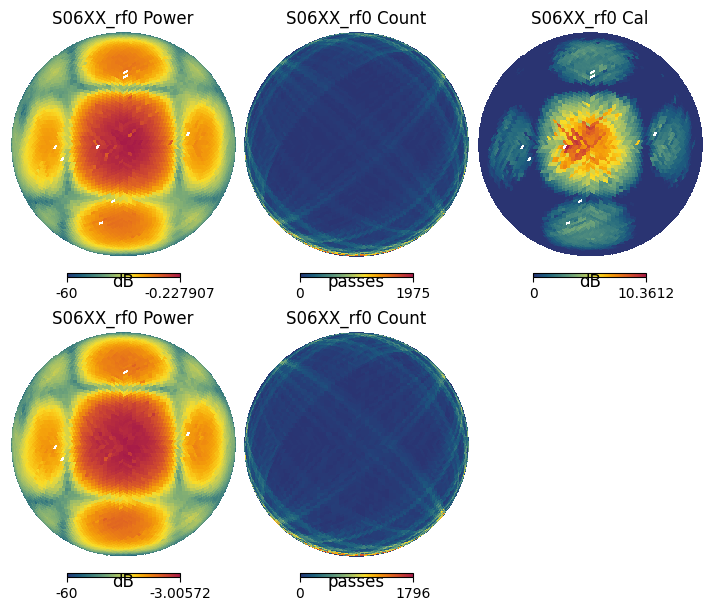

In [8]:
pf_mc = PassFile("../passes/monotonic_concave_cal/rf0/S06XX_rf0XX_passes.h5")
passes_mc = pf_mc.read_passes(pointing=0)

pf_orig = PassFile("../passes/rf0/S06XX_rf0XX_passes.h5")
passes_orig = pf_orig.read_passes(pointing=0)

pow_hpx_orig, count_hpx_orig = passes_to_healpix(passes_orig, nside=32)
pow_hpx_mc, cal_hpx_mc, count_hpx_mc, _, _ = passes_to_healpix_concave_monotonic(passes_mc, nside=32)

fig = plt.figure(figsize=(7, 6))

hp.orthview(pow_hpx_mc, fig=fig, sub=(2, 3, 1), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_mc, fig=fig, sub=(2, 3, 2), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count", unit="passes", cmap=prd)
hp.orthview(cal_hpx_mc, fig=fig, sub=(2, 3, 3), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Cal", unit="dB", cmap=prd)

hp.orthview(pow_hpx_orig, fig=fig, sub=(2, 3, 4), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_hpx_orig, fig=fig, sub=(2, 3, 5), rot=(0, 90, 180), half_sky=True, title="S06XX_rf0 Count", unit="passes", cmap=prd)

In [9]:
def plot_monotonic_concave_diagnostics(
    tile_ref,
    path_mc, 
    path_orig,
    out_dir,
    nside=32, 
    za_max=90, 
    figsize=(10, 8)
):
    """Plot diagnostics between new monotonic concave and original RFE calibration"""
    pf_mc = PassFile(f"{path_mc}/{tile_ref}_passes.h5")
    passes_mc = pf_mc.read_passes(pointing=0)

    pf_orig = PassFile(f"{path_orig}/{tile_ref}_passes.h5")
    passes_orig = pf_orig.read_passes(pointing=0)

    pow_hpx_mc, cal_hpx_mc, count_hpx_mc, fpf, fsf = passes_to_healpix_concave_monotonic(passes_mc, nside=nside)
    pow_hpx_orig, count_hpx_orig = passes_to_healpix(passes_orig, nside=nside)

    if "XX" in tile_ref:
        pidx=0
    else:
        pidx=1
    
    beam = mwa_hyperbeam.FEEBeam(os.environ["MWA_BEAM_FILE"])
    mwa_map = hyperbeam_healpix(
        beam,
        nside=nside,
        freq_hz=137e6,
        amps=np.ones(16),
    )
    hyperbeam_map = np.full(hp.nside2npix(32), np.nan, dtype=float)
    hyperbeam_map[: mwa_map.shape[0]] = mwa_map[:, pidx]

    hyp = healpix_ew_ns_slices(hyperbeam_map, nside=nside, za_max=za_max)
    sat_mc = healpix_ew_ns_slices(pow_hpx_mc, nside=nside, za_max=za_max)
    sat_orig = healpix_ew_ns_slices(pow_hpx_orig, nside=nside, za_max=za_max)

    ew_za, ew_sat_orig = sat_orig["EW"]
    _, ew_sat_mc = sat_mc["EW"]
    _, ew_hyp = hyp["EW"]

    ns_za, ns_sat_orig = sat_orig["NS"]
    _, ns_sat_mc = sat_mc["NS"]
    _, ns_hyp = hyp["NS"]

    fig = plt.figure(figsize=figsize)
    
    hp.orthview(
        pow_hpx_mc,
        fig=fig,
        sub=(2, 3, 1),
        rot=(0, 90, 180),
        half_sky=True,
        title="",
        unit="Beam Power [dB]",
        fontsize={'cbar_label': 10},
        format="%.2f",
        cmap=prd,
        min=-60,
    )
    
    hp.orthview(
        cal_hpx_mc,
        fig=fig,
        sub=(2, 3, 4),
        rot=(0, 90, 180),
        half_sky=True,
        title="",
        unit="Cal Power [dB]",
        fontsize={'cbar_label': 10},
        format="%.2f",
        cmap=prd,
    )
    
    # Create shared axes for the four slice panels.
    ax2 = fig.add_subplot(2, 3, 2)
    ax3 = fig.add_subplot(2, 3, 3, sharey=ax2)
    ax5 = fig.add_subplot(2, 3, 5, sharex=ax2)
    ax6 = fig.add_subplot(2, 3, 6, sharex=ax3, sharey=ax5)
    
    # EW slice in dB.
    ax2.plot(ew_za, ew_hyp, lw=1, ls=":", color="k", label="FEE")
    ax2.plot(ew_za, ew_sat_orig, lw=2, color=prd(0.9), label="SAT ORIG")
    ax2.plot(ew_za, ew_sat_mc, lw=2, color=prd(0.4), label="SAT MONO CONC")
    ax2.set_title("EW Slice")
    ax2.set_ylabel("Beam [dB]")
    ax2.legend(loc="lower center")
    
    # NS slice in dB.
    ax3.plot(ns_za, ns_hyp, lw=1, ls=":", color="k", label="FEE")
    ax3.plot(ns_za, ns_sat_orig, lw=2, color=prd(0.9), label="SAT ORIG")
    ax3.plot(ns_za, ns_sat_mc, lw=2, color=prd(0.4), label="SAT MONO CONC")
    ax3.set_title("NS Slice")
    ax3.legend(loc="lower center")
    
    # EW slice in linear units.
    ax5.plot(ew_za, 10 ** (0.1 * ew_hyp), lw=1, ls=":", color="k", label="FEE")
    ax5.plot(ew_za, 10 ** (0.1 * ew_sat_orig), lw=2, color=prd(0.9), label="SAT ORIG")
    ax5.plot(ew_za, 10 ** (0.1 * ew_sat_mc), lw=2, color=prd(0.4), label="SAT MONO CONC")
    ax5.set_xlabel("Zenith angle [deg]")
    ax5.set_ylabel("Beam [linear]")
    
    # NS slice in linear units.
    ax6.plot(ns_za, 10 ** (0.1 * ns_hyp), lw=1, ls=":", color="k", label="FEE")
    ax6.plot(ns_za, 10 ** (0.1 * ns_sat_orig), lw=2, color=prd(0.9), label="SAT ORIG")
    ax6.plot(ns_za, 10 ** (0.1 * ns_sat_mc), lw=2, color=prd(0.4), label="SAT MONO CONC")
    ax6.set_xlabel("Zenith angle [deg]")
    
    # Hide repeated tick labels.
    ax2.tick_params(labelbottom=False)
    ax3.tick_params(labelbottom=False, labelleft=False)
    ax6.tick_params(labelleft=False)
    
    # Reduce whitespace between the four right-hand panels.
    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        bottom=0.08,
        top=0.9,
        wspace=0.22,
        hspace=0.12,
    )

    fig.suptitle(f"{tile_ref} Monotonic Concave RFE Calibration Fit [Flagged Passes|Samples: {fpf:.2f}%|{fsf:.2f}%]", y=0.98, x=0.62)

    Path(out_dir).mkdir(parents=True, exist_ok=True)
    plt.savefig(f"{out_dir}/{tile_ref}_Monotonic_Concave_RFE_CalibrationFit.pdf")
    plt.show()

S06XX_rf0XX
Flagged passes: 3.42% (65/1900 passes)
Flagged data: 4.37% (43724/1000748 samples)


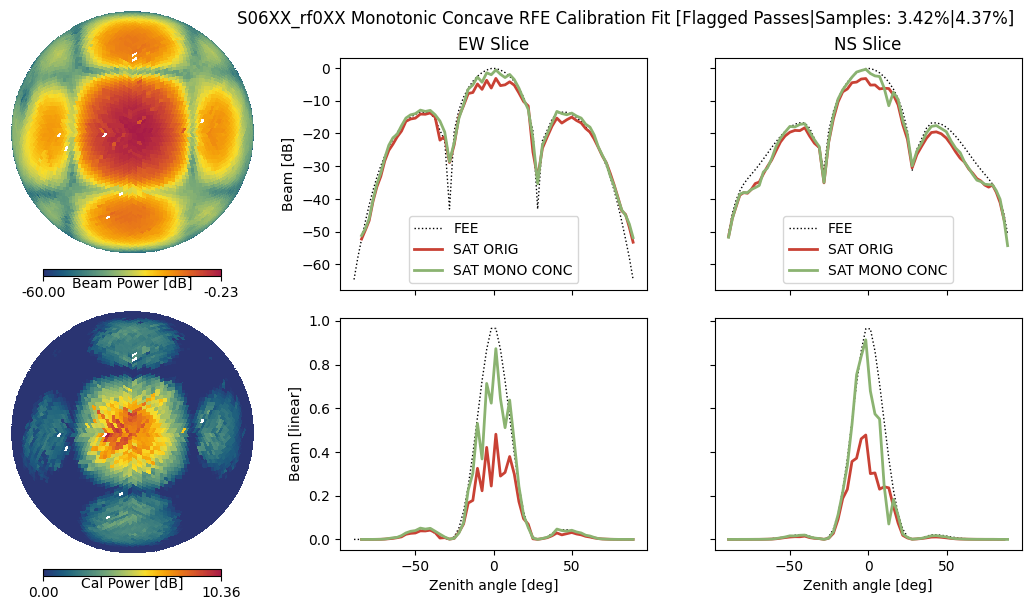

S07XX_rf0XX
Flagged passes: 3.81% (82/2153 passes)
Flagged data: 4.89% (54693/1118269 samples)


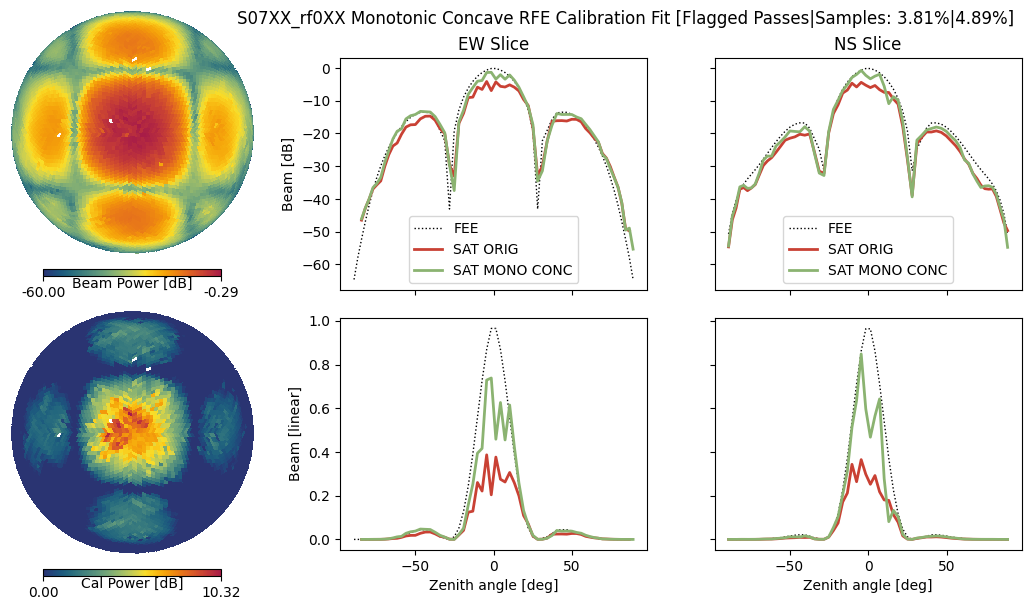

S08XX_rf0XX
Flagged passes: 5.00% (101/2021 passes)
Flagged data: 6.48% (66864/1032172 samples)


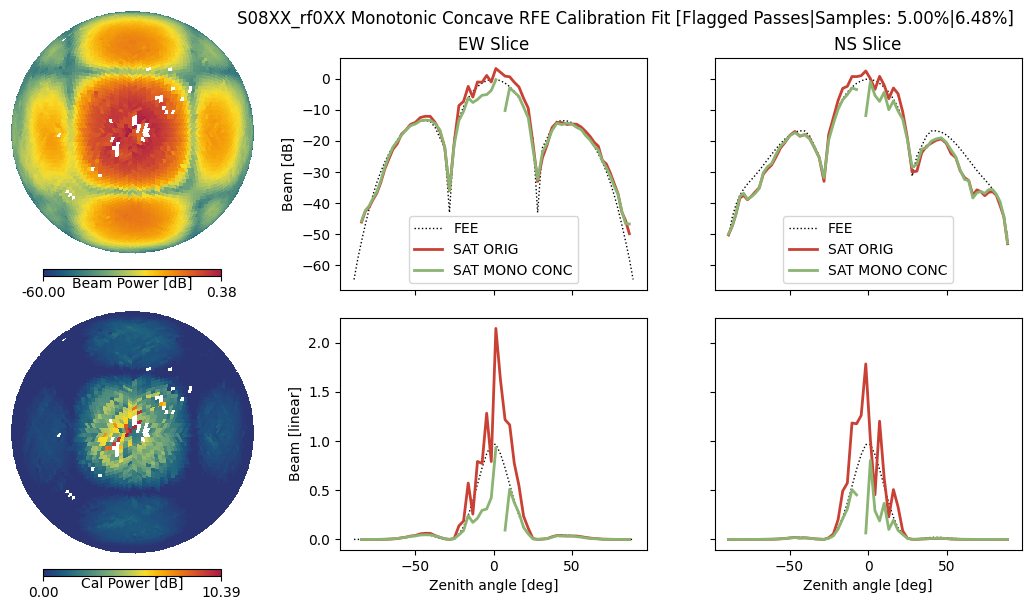

S09XX_rf0XX
Flagged passes: 5.42% (98/1809 passes)
Flagged data: 6.91% (64680/936649 samples)


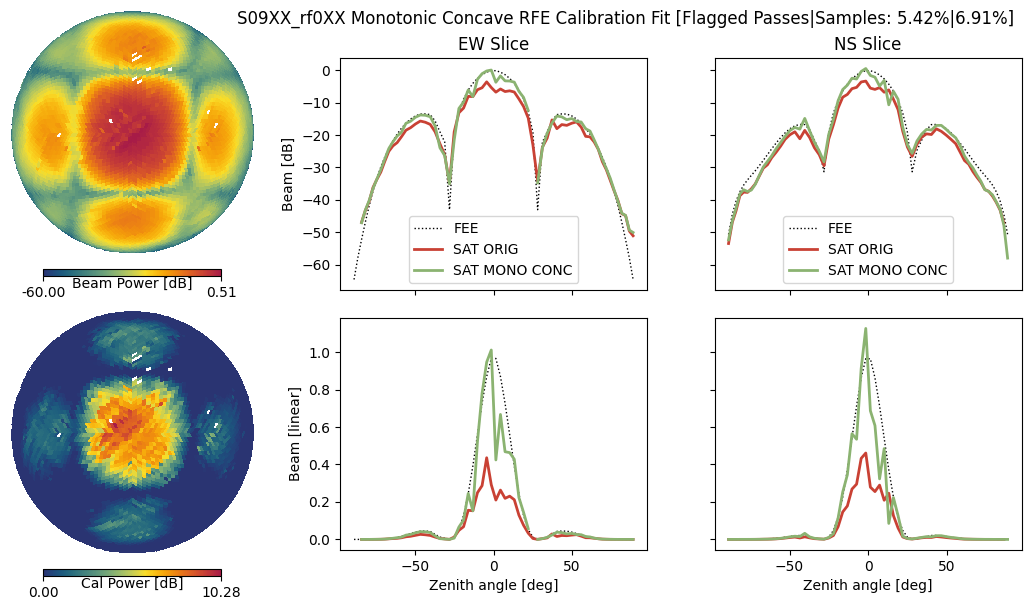

S10XX_rf0XX
Flagged passes: 5.96% (73/1224 passes)
Flagged data: 7.17% (44927/626830 samples)


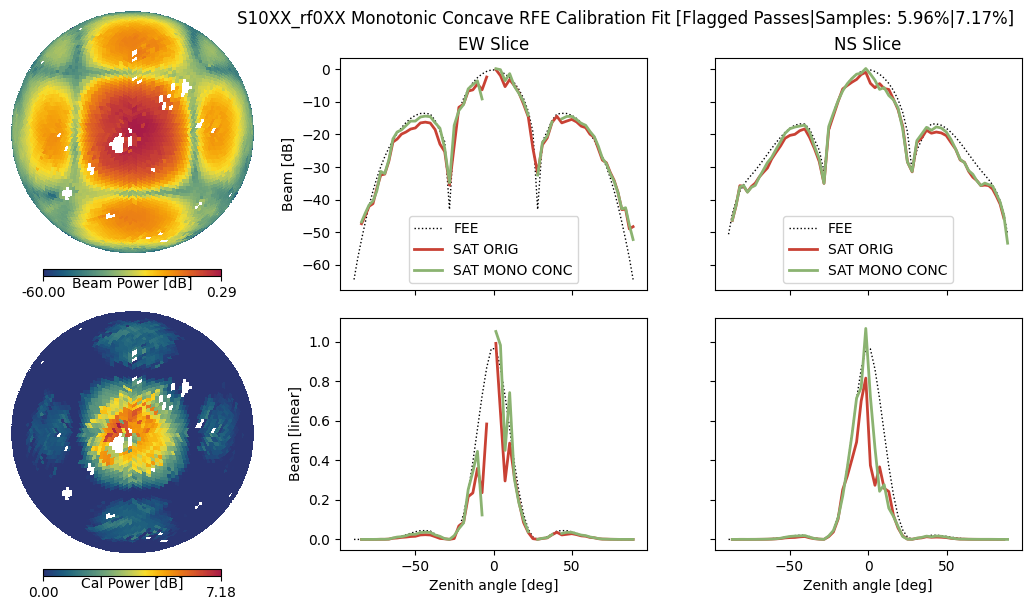

S12XX_rf0XX
Flagged passes: 4.22% (48/1137 passes)
Flagged data: 5.51% (30952/561420 samples)


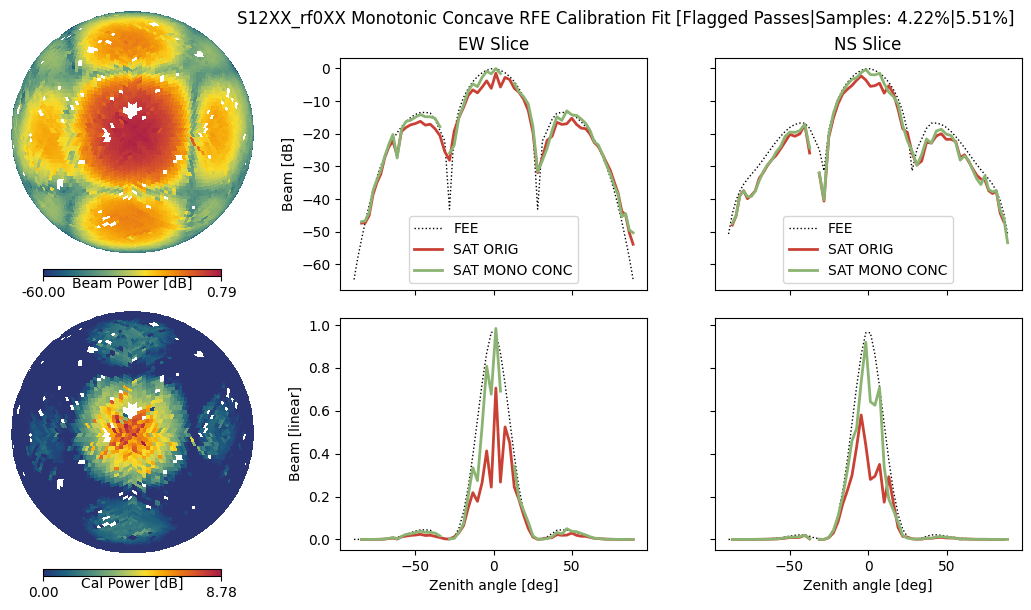

S29XX_rf0XX
Flagged passes: 4.40% (49/1113 passes)
Flagged data: 5.80% (33696/580936 samples)


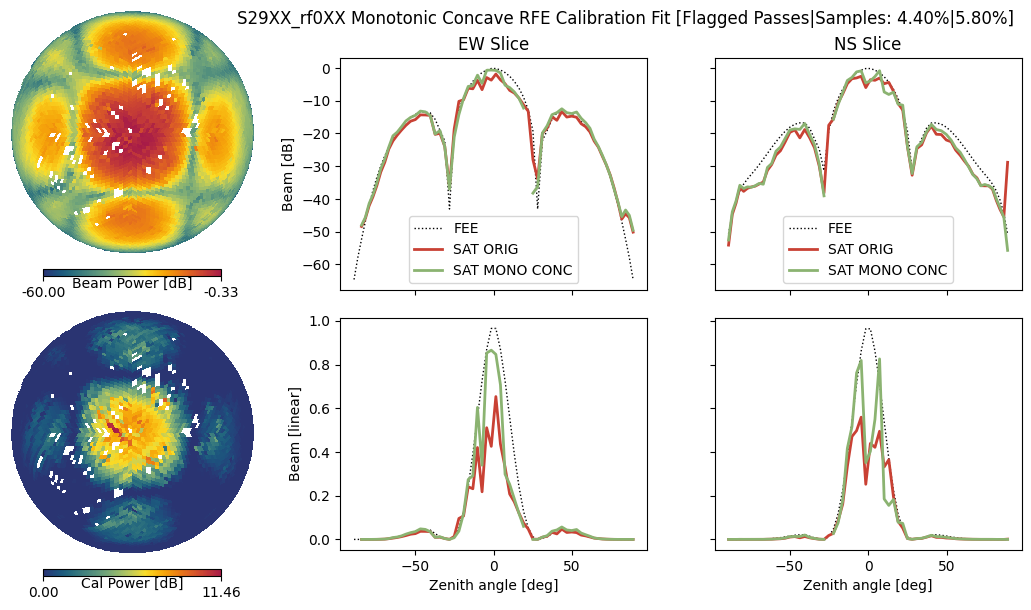

S30XX_rf0XX
Flagged passes: 3.34% (62/1859 passes)
Flagged data: 4.42% (42882/970771 samples)


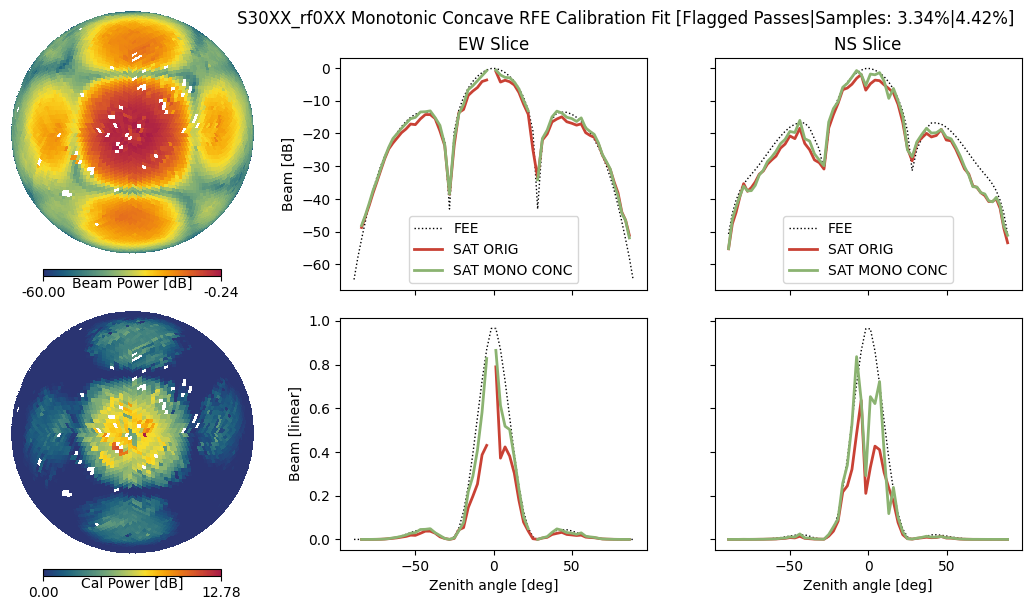

S31XX_rf0XX
Flagged passes: 3.09% (51/1652 passes)
Flagged data: 4.00% (34757/868870 samples)


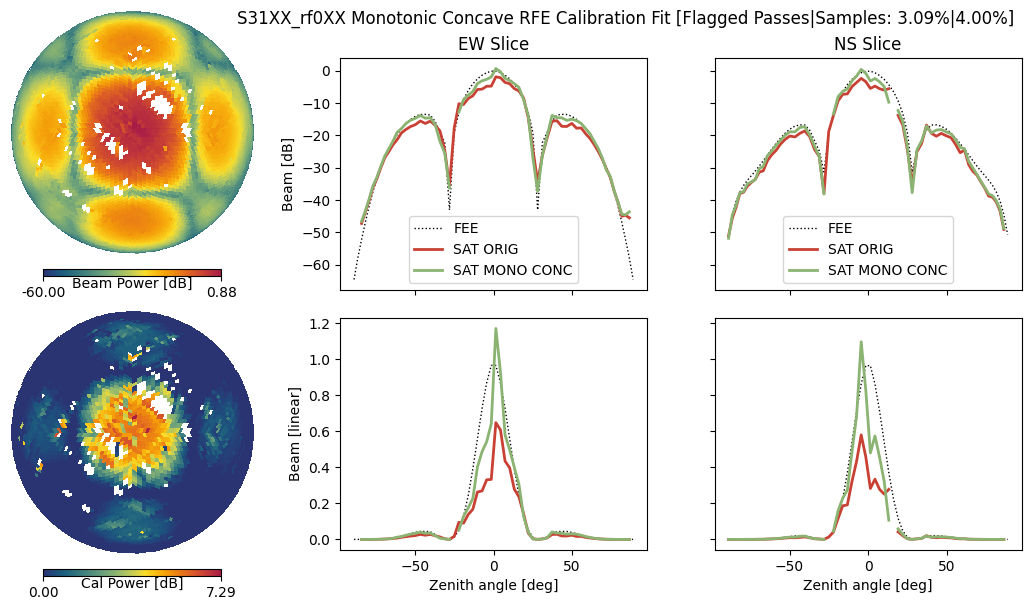

S32XX_rf0XX
Flagged passes: 2.81% (58/2061 passes)
Flagged data: 3.44% (36907/1074307 samples)


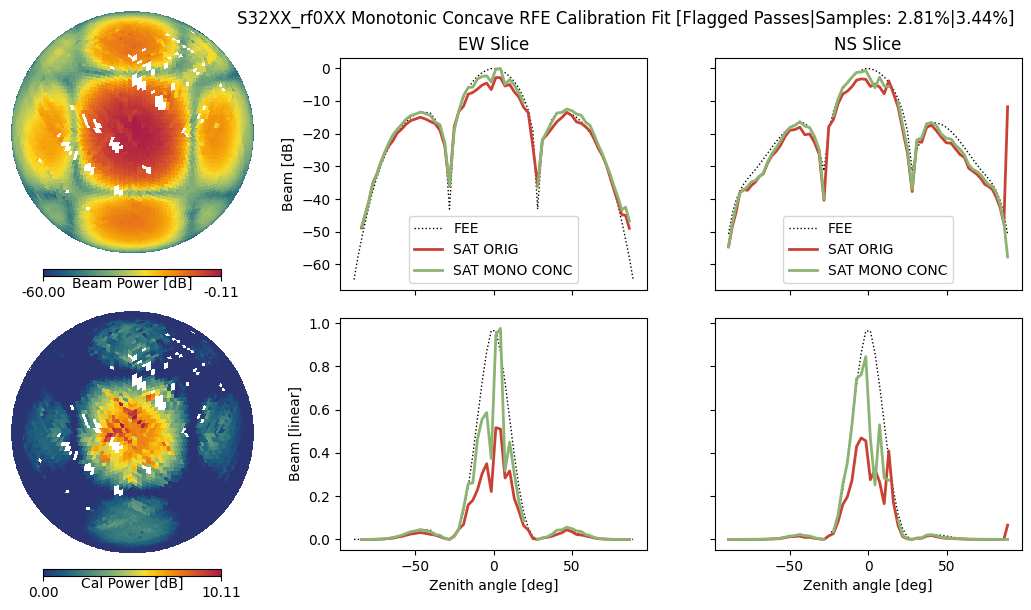

S33XX_rf0XX
Flagged passes: 3.21% (59/1836 passes)
Flagged data: 4.17% (40025/959533 samples)


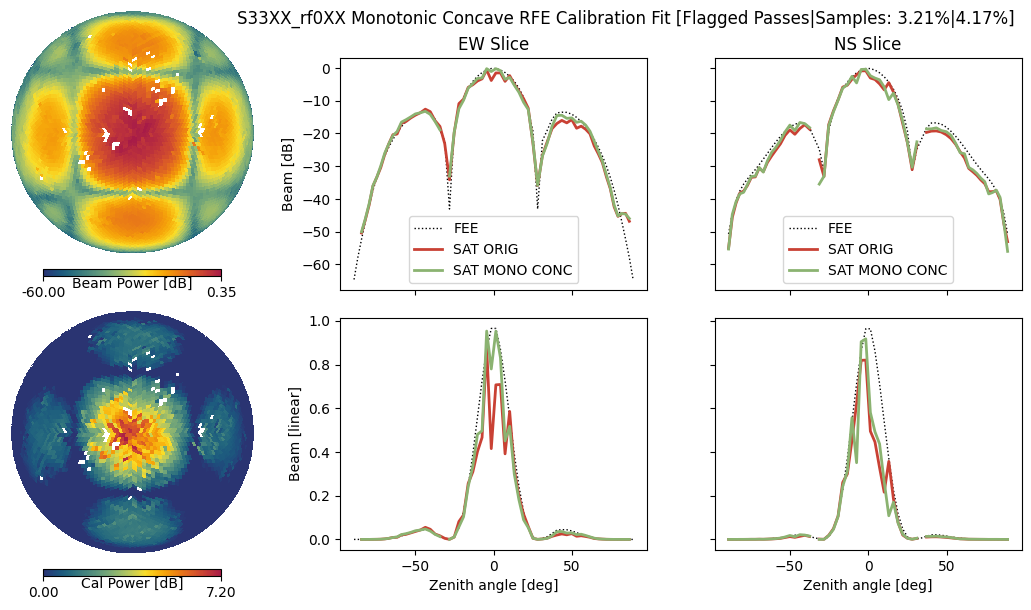

S34XX_rf0XX
Flagged passes: 4.00% (82/2052 passes)
Flagged data: 4.90% (52971/1080484 samples)


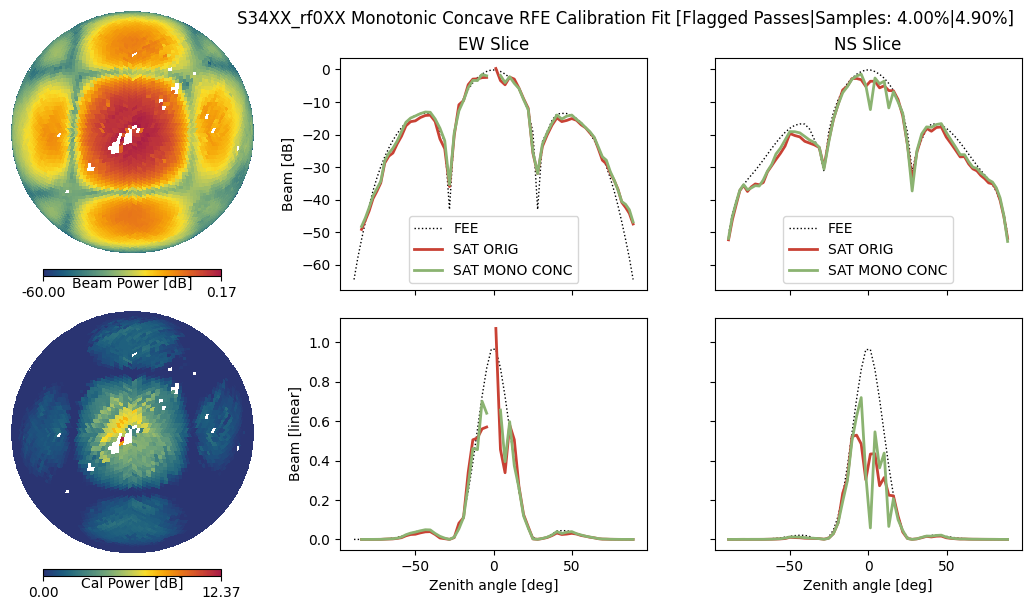

S35XX_rf0XX
Flagged passes: 3.28% (71/2167 passes)
Flagged data: 4.39% (48812/1112023 samples)


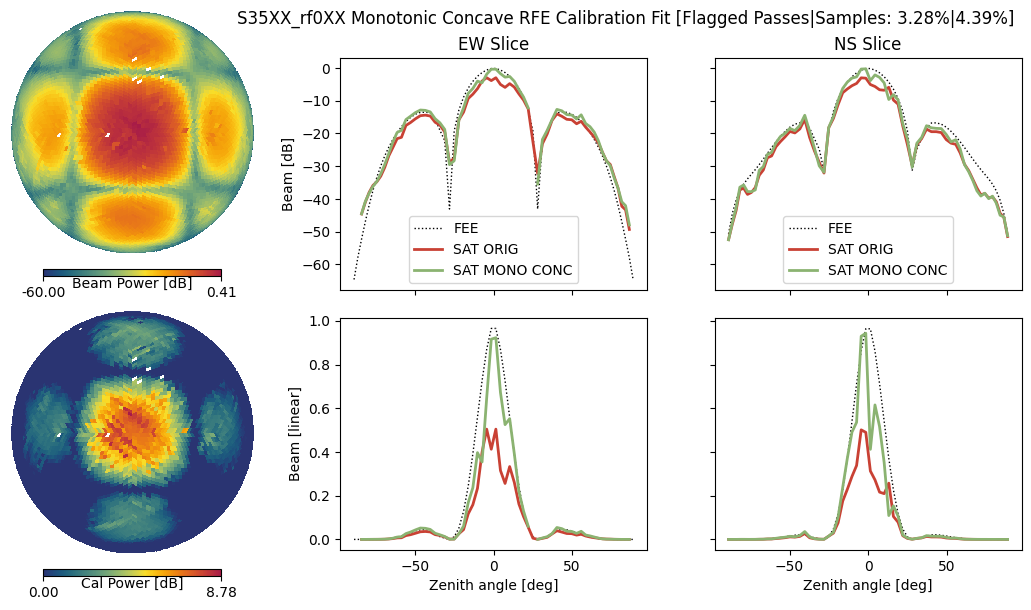

S36XX_rf0XX
Flagged passes: 3.14% (70/2228 passes)
Flagged data: 3.99% (46539/1167776 samples)


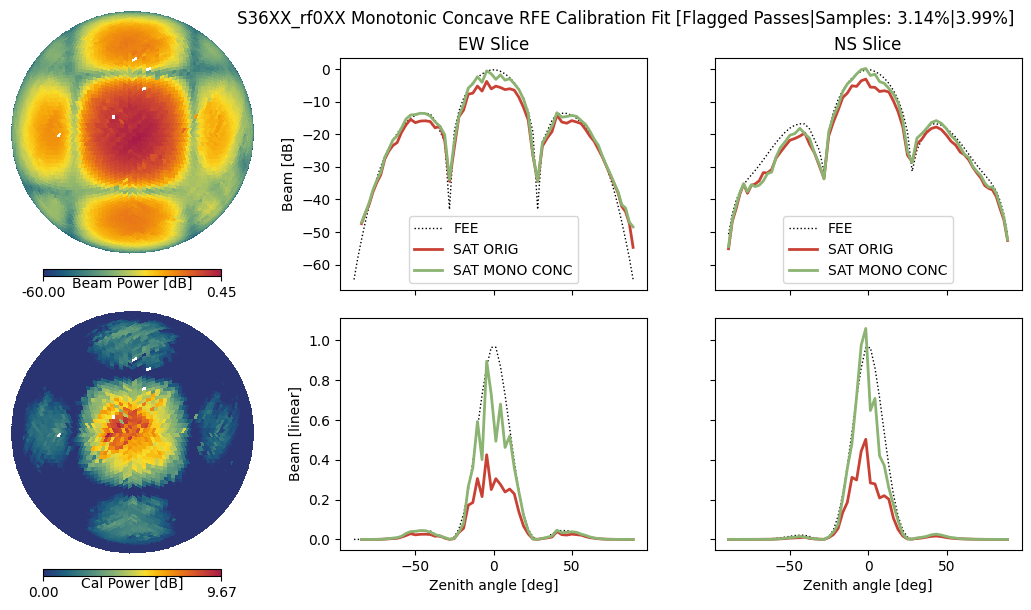

S06YY_rf0YY
Flagged passes: 6.30% (68/1079 passes)
Flagged data: 7.50% (43144/574921 samples)


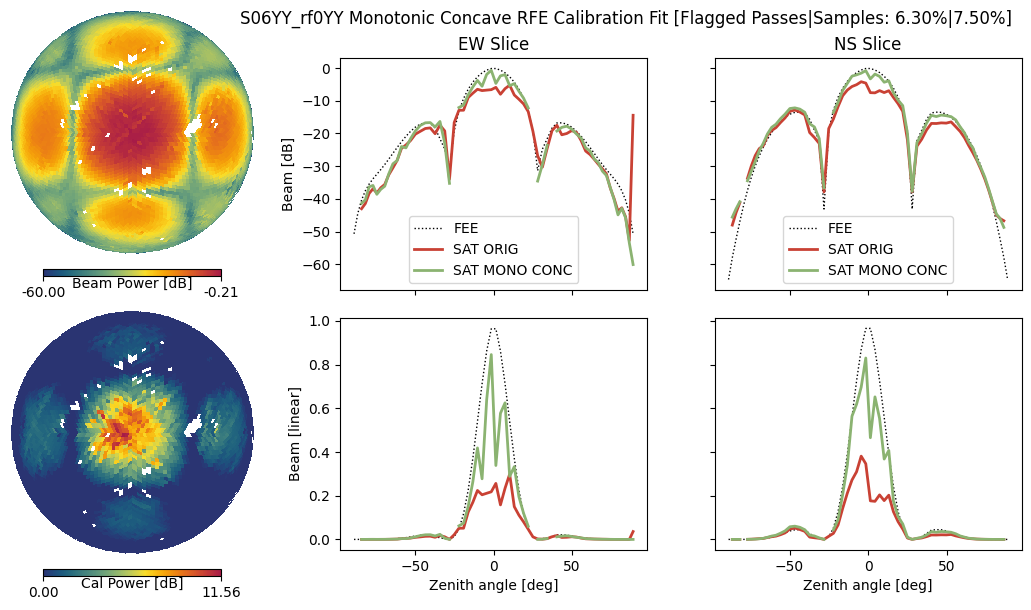

S07YY_rf0YY
Flagged passes: 7.03% (114/1621 passes)
Flagged data: 8.75% (75678/864568 samples)


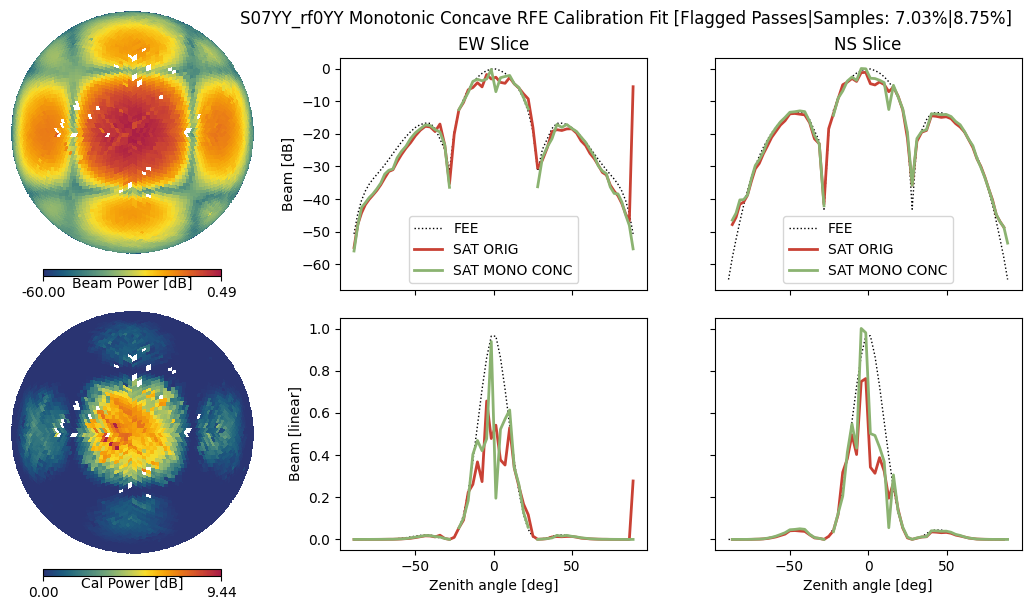

S08YY_rf0YY
Flagged passes: 4.61% (70/1520 passes)
Flagged data: 5.44% (44102/810884 samples)


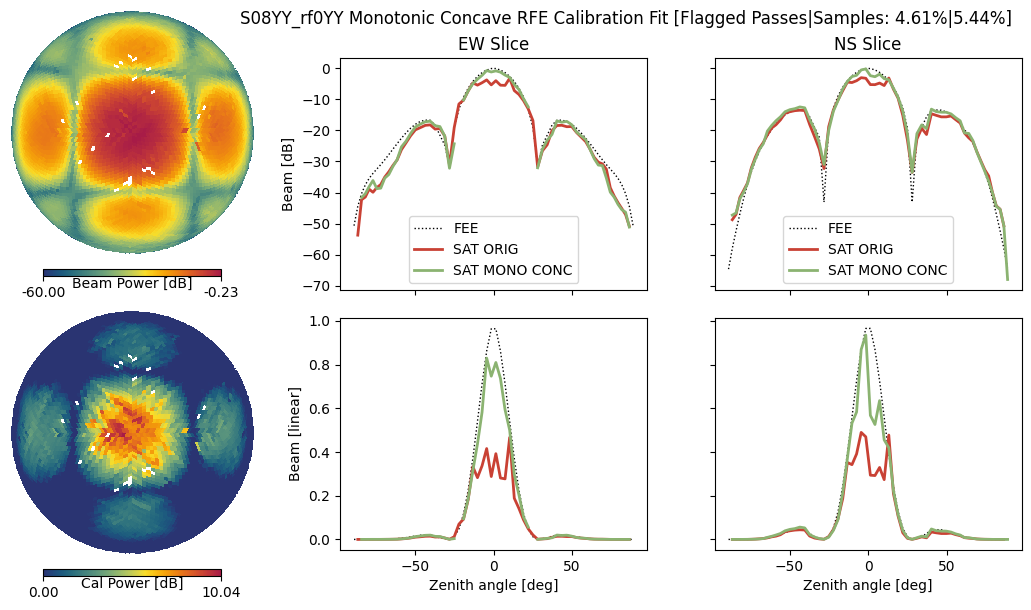

S09YY_rf0YY
Flagged passes: 4.74% (73/1541 passes)
Flagged data: 5.55% (44613/804233 samples)


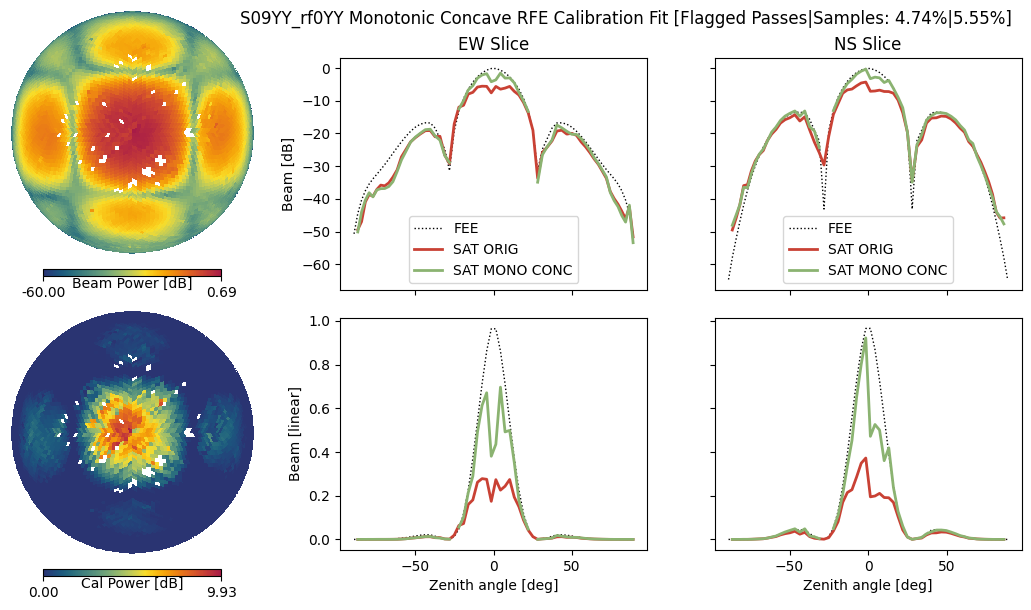

S10YY_rf0YY
Flagged passes: 7.03% (90/1281 passes)
Flagged data: 8.42% (56480/670744 samples)


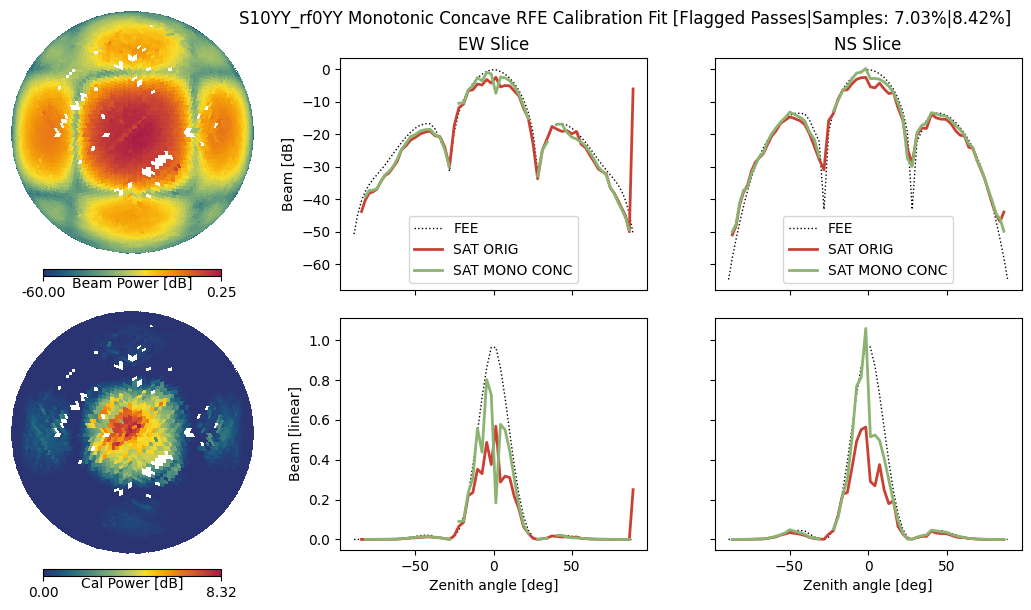

S12YY_rf0YY
Flagged passes: 8.62% (55/638 passes)
Flagged data: 12.01% (35593/296265 samples)


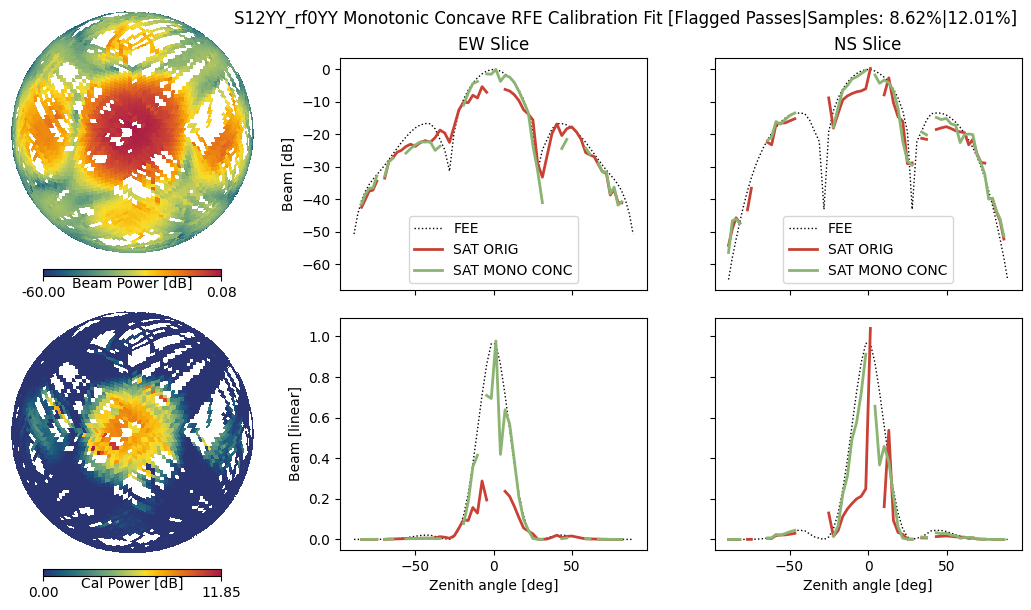

S29YY_rf0YY
Flagged passes: 5.98% (49/819 passes)
Flagged data: 7.89% (33747/427873 samples)


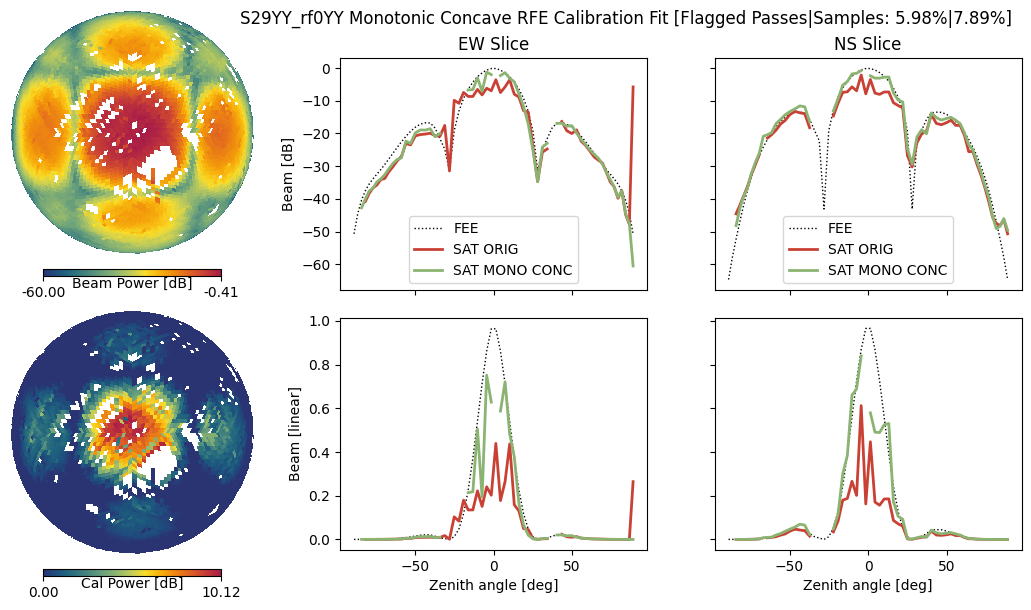

S30YY_rf0YY
Flagged passes: 4.49% (69/1538 passes)
Flagged data: 5.63% (46912/832868 samples)


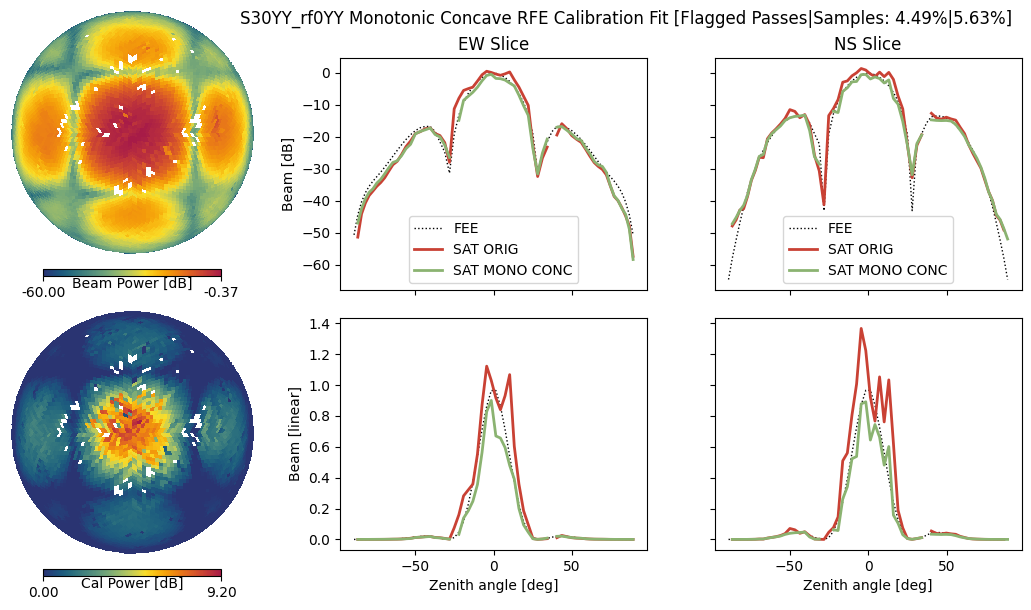

S31YY_rf0YY
Flagged passes: 5.02% (61/1214 passes)
Flagged data: 6.38% (40163/629786 samples)


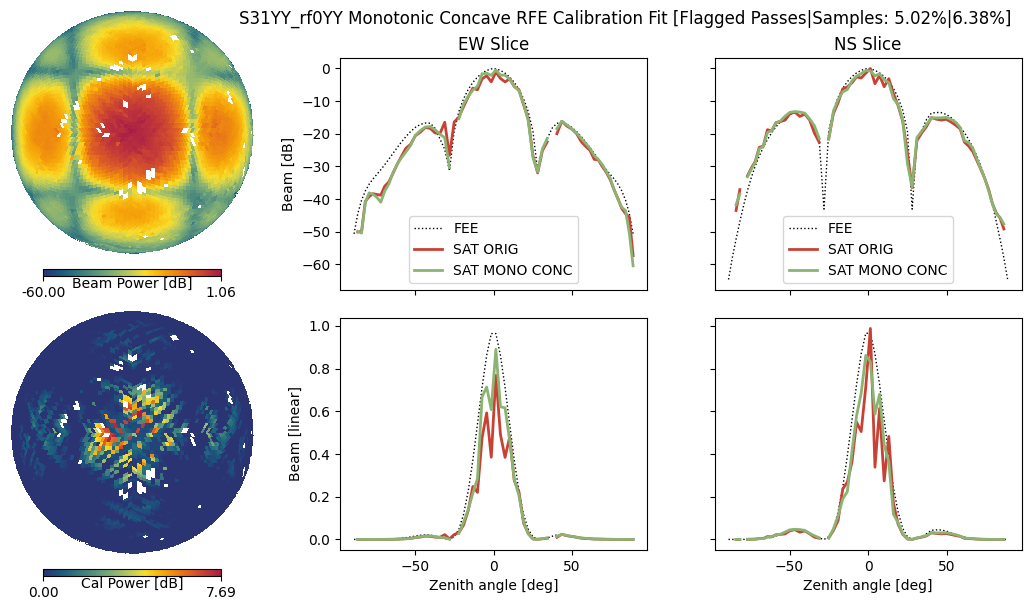

S32YY_rf0YY
Flagged passes: 4.80% (49/1020 passes)
Flagged data: 6.16% (32653/530207 samples)


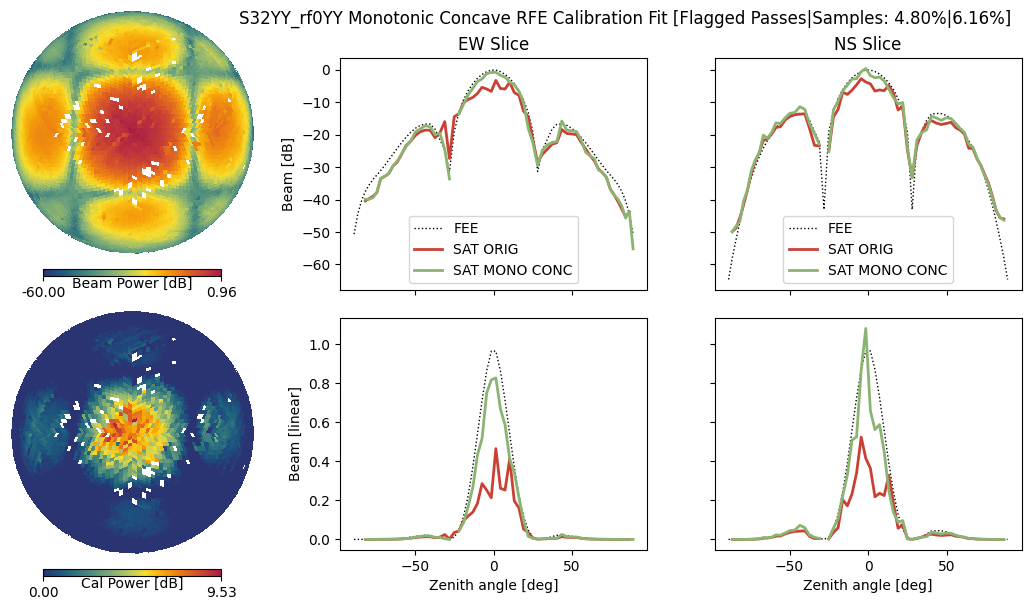

S33YY_rf0YY
Flagged passes: 4.75% (71/1494 passes)
Flagged data: 5.84% (46764/800081 samples)


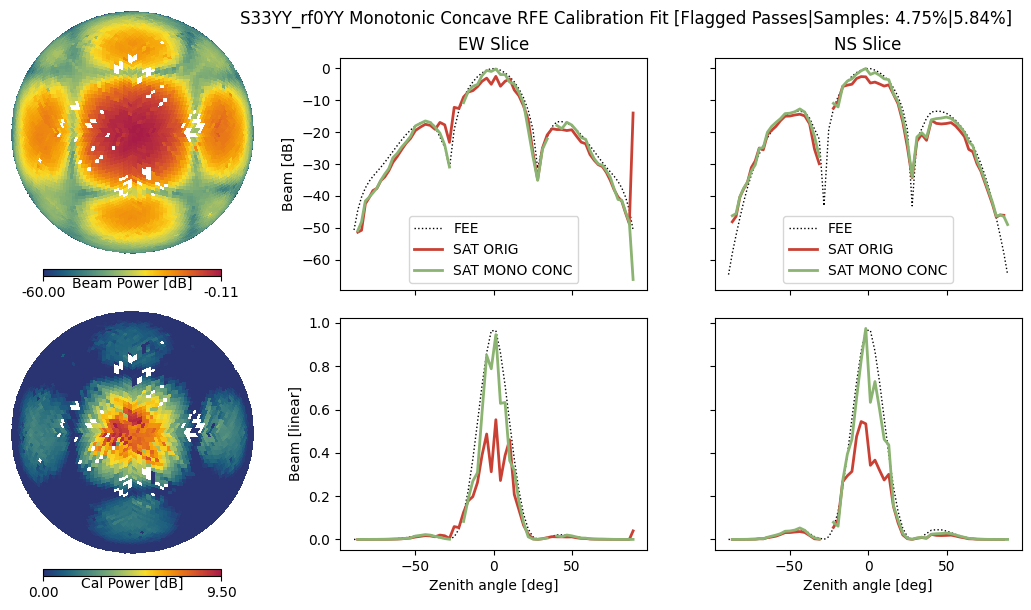

S34YY_rf0YY
Flagged passes: 4.86% (68/1398 passes)
Flagged data: 5.97% (43813/734390 samples)


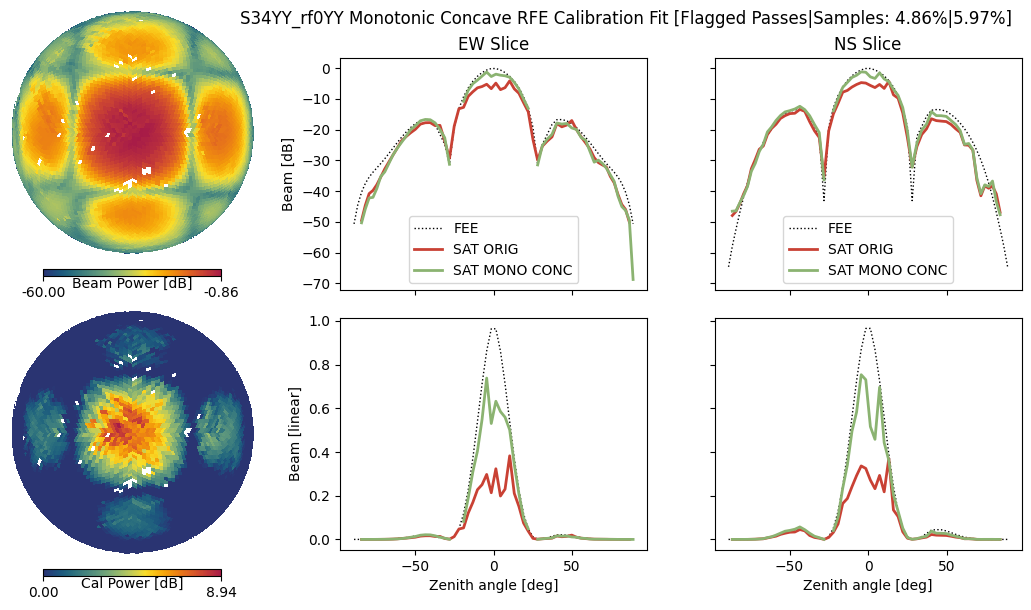

S35YY_rf0YY
Flagged passes: 6.72% (96/1429 passes)
Flagged data: 8.02% (61682/768858 samples)


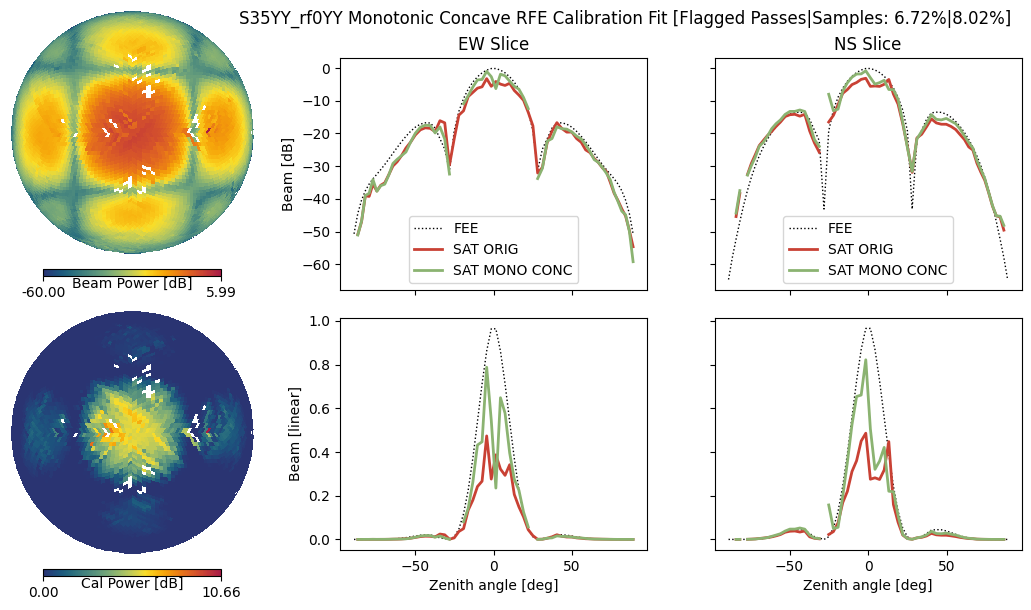

S36YY_rf0YY
Flagged passes: 4.58% (62/1355 passes)
Flagged data: 5.32% (38595/724830 samples)


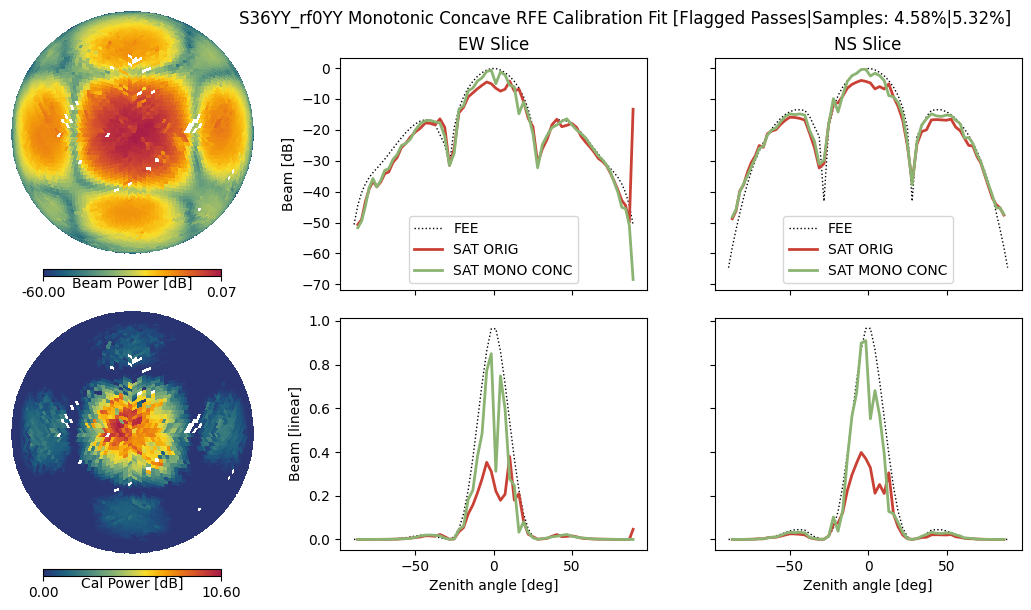

S06XX_rf1XX


FileNotFoundError: ../passes/monotonic_concave_cal/rf0/S06XX_rf1XX_passes.h5

In [10]:
tiles = [
    "S06XX",
    "S06YY",
    "S07XX",
    "S07YY",
    "S08XX",
    "S08YY",
    "S09XX",
    "S09YY",
    "S10XX",
    "S10YY",
    "S12XX",
    "S12YY",
    "S29XX",
    "S29YY",
    "S30XX",
    "S30YY",
    "S31XX",
    "S31YY",
    "S32XX",
    "S32YY",
    "S33XX",
    "S33YY",
    "S34XX",
    "S34YY",
    "S35XX",
    "S35YY",
    "S36XX",
    "S36YY",
]

refs = [
    "rf0XX",
    "rf0YY",
    "rf1XX",
    "rf1YY",
]

for ref in refs:
    for tile in tiles:
        if ref[3:] in tile:
            print(f"{tile}_{ref}")

            plot_monotonic_concave_diagnostics(
                tile_ref=f"{tile}_{ref}",
                path_mc="../passes/monotonic_concave_cal/rf0",
                path_orig="../passes/rf0",
                out_dir="../data/plots/monotonic_concave_rfe_cali",
                nside=32, 
                za_max=90,
                figsize=(11, 6))